In [625]:
from engioptiqa import AnnealingSolverAmplify, TrussStructure, TrussStructureOptimization

In [626]:
token_dict = {'fixstars': '/usr2/key/Projects/QuantumComputing/QuantumAnnealing/token_Fixstars.txt'}
proxy='http://proxy.ilsb.tuwien.ac.at:3128'
annealing_solver_gpu = AnnealingSolverAmplify(client_type='fixstars', token_file=token_dict['fixstars'], proxy=proxy)
annealing_solver_gpu.setup_solver()

Setting default timeout (ms): 800
Created solver


In [627]:
ts_opt = TrussStructureOptimization()

In [628]:
ts_opt.add_node(0, (0,0))  # Node 0 at (0,0)
ts_opt.add_node(1, (1,0))  # Node 1 at (1,0)
ts_opt.add_node(2, (1,1))  # Node 2 at (1,1)
ts_opt.add_node(3, (0,1))  # Node 3 at (0,1)

In [629]:
ts_opt.add_member(0, 1, A=0.5, E=2e11)  # Member from Node 0 to Node 1
ts_opt.add_member(1, 2, A=0.5, E=2e11)  # Member from Node 1 to Node 2
ts_opt.add_member(2, 3, A=0.5, E=2e11)  # Member from Node 2 to Node 3
ts_opt.add_member(3, 0, A=0.5, E=2e11)  # Member from Node 3 to Node 0
ts_opt.add_member(0, 2, A=0.5, E=2e11)  # Diagonal Member from Node 0 to Node 2
ts_opt.add_member(1, 3, A=0.5, E=2e11)  # Diagonal Member from Node 1 to Node 3

In [630]:
ts_opt.add_load(1, (0, -100e3))  # Vertical load of -100 N at Node 1

In [631]:
ts_opt.add_support(0, True, True)  # Fixed support at Node 0
ts_opt.add_support(3, True, True)  # Fixed support at Node 3

Max Area: 0.5


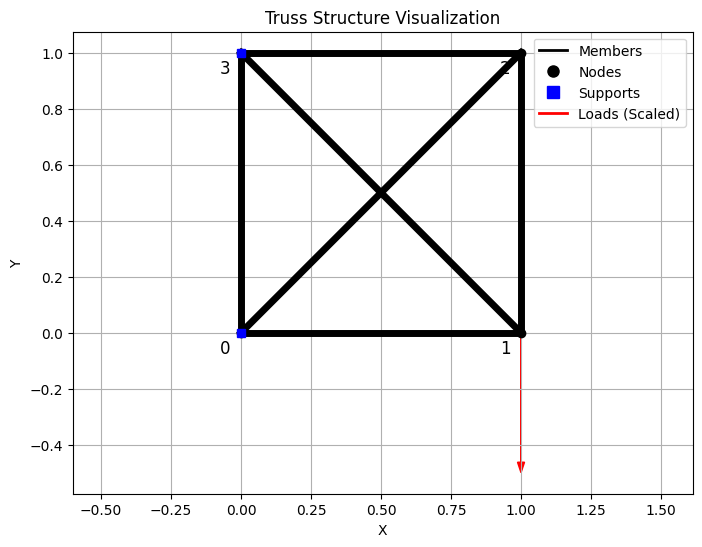

In [632]:
ts_opt.visualize_truss()

In [633]:
member_areas = [member.A for member in ts_opt.members]
V_0 = ts_opt.total_volume(member_areas)
print(f"Initial total volume: {V_0}")

Initial total volume: 3.414213562373095


In [634]:
ts_opt.generate_discretization(n_qubits_per_member=16,
                               binary_representation='range',
                               lower_lim=-4e5, upper_lim=4e5)

TrussStructureOptimization: Generating member area inverse polynomials.


In [635]:
ts_opt.generate_objective(penalty_weight_joints=1e-1, target_volume=V_0, penalty_weight_volume=1e3)

Node 0
Node 1
	Residual force in x-direction: - 6.10360875867857 q_0 q''''''_0 - 12.2072175173571 q_1 q''''''_0 - 24.4144350347143 q_2 q''''''_0 - 48.8288700694285 q_3 q''''''_0 - 97.6577401388571 q_4 q''''''_0 - 195.315480277714 q_5 q''''''_0 - 390.630960555428 q_6 q''''''_0 - 781.261921110857 q_7 q''''''_0 - 1562.52384222171 q_8 q''''''_0 - 3125.04768444343 q_9 q''''''_0 - 6250.09536888685 q_{10} q''''''_0 - 12500.1907377737 q_{11} q''''''_0 - 25000.3814755474 q_{12} q''''''_0 - 50000.7629510948 q_{13} q''''''_0 - 100001.52590219 q_{14} q''''''_0 - 200003.051804379 q_{15} q''''''_0 - 4.31590314297122 q'''''_0 q'''''''''''_0 - 8.63180628594244 q'''''_1 q'''''''''''_0 - 17.2636125718849 q'''''_2 q'''''''''''_0 - 34.5272251437698 q'''''_3 q'''''''''''_0 - 69.0544502875395 q'''''_4 q'''''''''''_0 - 138.108900575079 q'''''_5 q'''''''''''_0 - 276.217801150158 q'''''_6 q'''''''''''_0 - 552.435602300316 q'''''_7 q'''''''''''_0 - 1104.87120460063 q'''''_8 q'''''''''''_0 - 2209.74240920127 q''

In [636]:
annealing_solver_gpu.solve_qubo_problem(ts_opt)

Number of solutions: 1


In [637]:
best_solution, solutions = ts_opt.analyze_results()

Node 0
Node 1
	Residual force in x-direction: 1668.8825455412589
	Residual force in y-direction:  -1664.304838972239
Node 2
	Residual force in x-direction: 0.0
	Residual force in y-direction:  0.0
Node 3
Best solution (minimum objective):
Objective: 556715.2483227963
Complementary Energy: 0.18675774154958888
Volume: 1.2071067811865475
Joint Residuals (squared): 5555079.547838682
Member Forces: [-100004.57770656902, -0.0, 0.0, -0.0, 0.0, 139067.6737621118]
Member Stresses: [-200009.15541313804, -76887.15953307395, 30353.246356908465, -400000.0, 332030.2128633554, 278135.3475242236]
Member Areas: [0.5, 0.0, 0.0, 0.0, 0.0, 0.5]


Max Area: 0.5


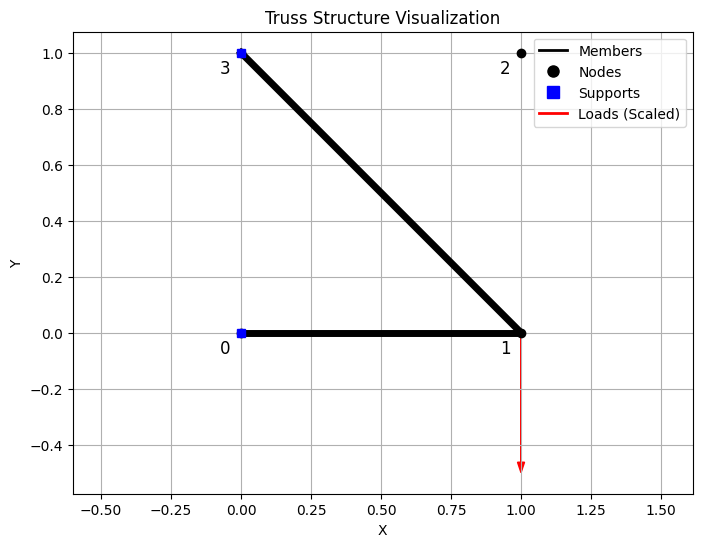

In [638]:
ts_opt.set_member_areas(best_solution['member_areas'])
ts_opt.visualize_truss()

Max Area: 0.5


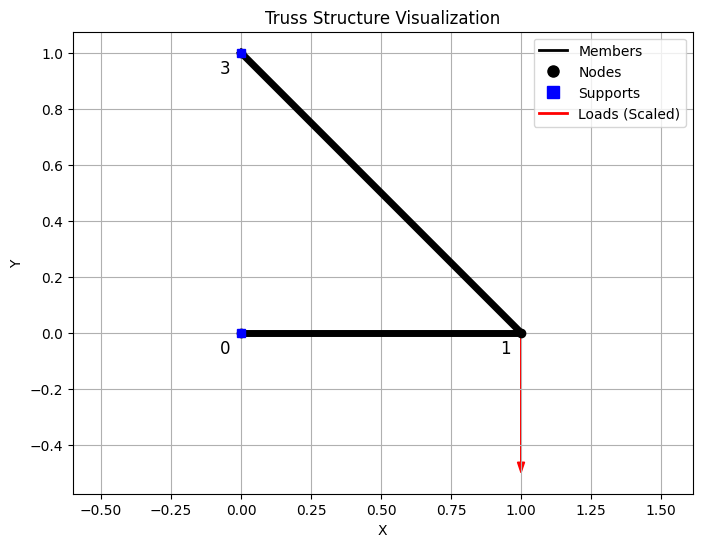

In [639]:
ts_ref = TrussStructure()

nodes_ref = {}
for i_member, member_area in enumerate(best_solution['member_areas']):
    if member_area > 0:
        member_nodes = (ts_opt.members[i_member].node_id_0, ts_opt.members[i_member].node_id_1)
        if member_nodes[0] not in nodes_ref:
            ts_ref.add_node(member_nodes[0], ts_opt.members[i_member].get_coords(0))
        if member_nodes[1] not in nodes_ref:
            ts_ref.add_node(member_nodes[1], ts_opt.members[i_member].get_coords(1))
        ts_ref.add_member(member_nodes[0], member_nodes[1], A=member_area , E=2e11, member_id=i_member)

ts_ref.add_load(1, (0, -100e3))  # Vertical load of -100 N at Node 1
ts_ref.add_support(0, True, True)  # Fixed support at Node 0
ts_ref.add_support(3, True, True)  # Fixed support at Node 3
ts_ref.visualize_truss()

In [640]:
raise Exception()

Exception: 

In [ ]:
member_forces, compliance = ts_ref.compute_member_forces()
rel_error_compliance = abs((compliance-2*best_solution["complementary_energy"]))/abs(compliance)
print('Compliance:')
print('===========')
print(f'  Reference: {compliance:.8e}')
print(f'  Solution {2*best_solution["complementary_energy"]:.8e}')
print(f'  Rel. Diff: {rel_error_compliance:.2e}')
print('Force:')
print('======')
for i_member_ref, member in enumerate(ts_ref.members):
    i_member = member.member_id
    rel_error_force = abs((member_forces[i_member_ref]-best_solution["member_forces"][i_member]))/abs(member_forces[i_member_ref])
    print(f'  Member {i_member}:')
    print(f'    Reference: {member_forces[i_member_ref]:.8e}')
    print(f'    Solution {best_solution["member_forces"][i_member]:.8e}')
    print(f'    Rel. Diff: {rel_error_force:.2e}')

Compliance: 0.38284271247461915
Compliance:
  Reference: 3.82842712e-01
  Solution 3.12260350e-01
  Rel. Diff: 1.84e-01
Force:
  Member 0:
    Reference: -1.00000000e+05
    Solution -9.06660563e+04
    Rel. Diff: 9.33e-02
  Member 5:
    Reference: 1.41421356e+05
    Solution 1.27544060e+05
    Rel. Diff: 9.81e-02
